# SafeX AI Attendance Automation — Demo Notebook
**Business Automation Research — Group 25 — Week 2 Individual Module**

Demonstrates the full flow using Flask's `test_client`, so it runs standalone
without a separate server process. To run the real app with camera QR
scanning in a browser, see the main `README.md`.

**Flow demonstrated:**
1. Register a sample employee + generate their QR code
2. Check in from *inside* the office geofence -> `PRESENT`/`LATE`
3. Duplicate check-in same day -> `DUPLICATE`
4. Check in from *outside* the geofence -> `REJECTED_LOCATION`
5. Check in with a forged/invalid QR token -> `REJECTED_QR`
6. Pull the attendance report + AI-generated dashboard insights


In [1]:
import sys, os, pathlib
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

db_path = pathlib.Path("database/attendance.db")
if db_path.exists():
    db_path.unlink()

from app import app
from services.qr_service import sign_employee_token, generate_and_save_employee_qr

client = app.test_client()


## 1. Register a sample employee + view their generated QR code

In [2]:
resp = client.post("/api/employees", json={
    "employee_id": "EMP-001",
    "full_name": "Ayesha Khan",
    "department": "Engineering",
    "phone": "+923001234567",
})
resp.get_json()


{'employee': {'department': 'Engineering',
  'email': None,
  'employee_id': 'EMP-001',
  'full_name': 'Ayesha Khan',
  'phone': '+923001234567'},
 'qr_path': '/static/qr/EMP-001.png'}

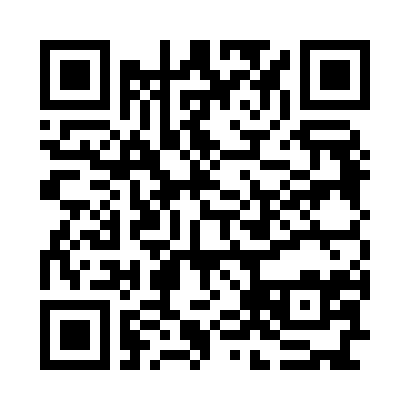

In [3]:
from IPython.display import Image, display
from pathlib import Path
qr_path = Path("static/qr/EMP-001.png")
if not qr_path.exists():
    generate_and_save_employee_qr("EMP-001", Path("static/qr"))
display(Image(filename=str(qr_path)))


## 2. Sample Input/Output — Check-in inside the geofence
This is what happens when the employee scans their QR (decoded token below) and
their phone reports GPS coordinates ~15m from the registered office.

In [4]:
token = sign_employee_token("EMP-001")
result = client.post("/checkin", json={"token": token, "latitude": 27.7053, "longitude": 68.8575})
result.get_json()


{'checkin_time': '2026-07-18T22:02:30.295142+00:00',
 'distance_m': 14.9,
 'employee_id': 'EMP-001',
 'message': 'Welcome Ayesha Khan! Attendance marked as LATE.',
 'status': 'LATE'}

## 3. Duplicate check-in same day — should be rejected, not double-counted

In [5]:
result = client.post("/checkin", json={"token": token, "latitude": 27.7053, "longitude": 68.8575})
result.get_json()


{'checkin_time': '2026-07-18T22:02:30.309149+00:00',
 'distance_m': None,
 'employee_id': 'EMP-001',
 'message': 'Ayesha Khan has already checked in today.',
 'status': 'DUPLICATE'}

## 4. Check-in from outside the geofence (different employee)

In [6]:
client.post("/api/employees", json={"employee_id": "EMP-002", "full_name": "Bilal Ahmed", "department": "Sales"})
token2 = sign_employee_token("EMP-002")
result = client.post("/checkin", json={"token": token2, "latitude": 27.8000, "longitude": 68.9000})
result.get_json()


{'checkin_time': '2026-07-18T22:02:30.333760+00:00',
 'distance_m': 11344.2,
 'employee_id': 'EMP-002',
 'message': 'You are 11344m from the office — outside the allowed 150.0m radius.',
 'status': 'REJECTED_LOCATION'}

## 5. Check-in with a forged/invalid QR token — never trusted without a valid signature

In [7]:
result = client.post("/checkin", json={"token": "forged-token-attempt", "latitude": 27.7053, "longitude": 68.8575})
result.get_json()


{'checkin_time': '2026-07-18T22:02:30.346608+00:00',
 'distance_m': None,
 'employee_id': None,
 'message': 'QR code could not be verified. Please use your official employee QR.',
 'status': 'REJECTED_QR'}

## 6. Attendance report (Pandas-based)

In [8]:
import pandas as pd
report = client.get("/api/attendance/report").get_json()
pd.DataFrame(report["records"])


,attendance_date,attendance_id,check_in_time,department,employee_id,full_name,latitude,longitude,status
0,2026-07-18,2,2026-07-18T22:02:30.333760+00:00,Sales,EMP-002,Bilal Ahmed,27.8000,68.9000,REJECTED_LOCATION
1,2026-07-18,1,2026-07-18T22:02:30.295142+00:00,Engineering,EMP-001,Ayesha Khan,27.7053,68.8575,LATE


## 7. AI-generated dashboard insights\nUses Gemini if `GEMINI_API_KEY` is set in `.env`, otherwise a rule-based fallback (shown below).

In [9]:
dash = client.get("/dashboard")
print("dashboard status:", dash.status_code)

from services.ai_service import generate_attendance_insights
sample_stats = {"date": "2026-07-16", "total_employees": 5, "present": 2, "late": 1, "absent": 2}
generate_attendance_insights(sample_stats)


dashboard status: 200


{'attendance_rate_percent': 60.0,
 'health_score': 'Needs attention',
 'summary': '3 of 5 employees present today (60.0%). 1 late, 2 not yet checked in.',
 'recommendations': ['1 employee(s) arrived late today — consider a reminder about office start time.',
  '2 employee(s) have not checked in yet — follow up if this continues.'],
 'source': 'rule_based_fallback'}